# **FICO® Xpress MoselPy - Chapter I: Timetabling and Personnel**

***timetabling_personnel.ipynb*** - Timetabling and personnel scheduling problems from the Xpress Applications Book - worker assignment, nurse scheduling, school timetabling, exam scheduling, production planning with transfers, and construction site staffing, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
import moselpy as mp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/timetabling_personnel"
DATA   = "data/timetabling_personnel"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Timetabling and personnel scheduling problems

This notebook covers six IP examples from Chapter I of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples include worker-to-machine assignment, nurse scheduling with cyclic shifts, school timetabling, exam scheduling, production planning with personnel transfers, and construction site staffing.

> **Mosel source files:** [`models/timetabling_personnel/`](models/timetabling_personnel/) &nbsp;|&nbsp; **Data files:** [`data/timetabling_personnel/`](data/timetabling_personnel/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_9)

### MoselPy features demonstrated in this chapter

- **Two sequential solves in one call**: the model solves LP relaxation then MIP (I-1), or solves with then without a constraint (I-2, I-5), returning all results from a single `execute_model`.
- **Named `linctr` constraints reassigned between solves**: `Load` in I-5 and `Period` in I-2 are redefined in-place without rebuilding the model.
- **Dynamic arrays with `exists()` and `create()`**: transfer variables created only for permitted line pairs (I-5).
- **Feasibility solve**: `minimize(0)` finds any feasible timetable; `is_solution_available` confirms feasibility (I-4).
- **3D array result from Python**: `sol_teach` indexed by (teacher, class, slot) reconstructed as a weekly grid (I-3).

## I-1 Personnel assignment (IP)

*Applications Book Chapter I, Example 1*

> **Mosel model:** [`i1assign_p.mos`](models/timetabling_personnel/i1assign_p.mos)

Six operators must each be assigned to one of six machines in a workshop. Two objectives are considered: (1) **parallel machines** - maximize total productivity across all assignments; (2) **serial machines** - maximize the bottleneck (minimum) productivity, since overall throughput is limited by the slowest assignment.

The model solves both problems in sequence: the LP relaxation of the parallel problem is solved first (which happens to produce integer values due to total unimodularity), then binary constraints and the bottleneck variable are added for the serial solve.

**Sets:** $\text{PERS} = 1..6$, $\text{MACH} = 1..6$

**Parameters:** $\text{OUTP}_{p,m}$ - productivity of person $p$ on machine $m$

**Decision variables:** $\mathit{assign}_{p,m} \in \{0,1\}$ - 1 if person $p$ assigned to machine $m$; $\mathit{pmin}$ - minimum productivity (serial problem only)

$$
\begin{align*}
\text{(parallel)} \quad \text{maximize} \quad & \sum_{p,m} \text{OUTP}_{p,m} \cdot \mathit{assign}_{p,m} \\
\text{(serial)}   \quad \text{maximize} \quad & \mathit{pmin} \\
\text{subject to} \quad & \sum_m \mathit{assign}_{p,m} = 1 \quad \forall\, p \\
                          & \sum_p \mathit{assign}_{p,m} = 1 \quad \forall\, m \\
                          & \sum_m \text{OUTP}_{p,m} \cdot \mathit{assign}_{p,m} \geq \mathit{pmin} \quad \forall\, p \quad \text{(serial only)}
\end{align*}
$$

Define the 6x6 productivity matrix as a dict with `(person, machine)` tuple keys.

In [ ]:
OUTP = {
    (1,1):13,(1,2):24,(1,3):31,(1,4):19,(1,5):40,(1,6):29,
    (2,1):18,(2,2):25,(2,3):30,(2,4):15,(2,5):43,(2,6):22,
    (3,1):20,(3,2):20,(3,3):27,(3,4):25,(3,5):34,(3,6):33,
    (4,1):23,(4,2):26,(4,3):28,(4,4):18,(4,5):37,(4,6):30,
    (5,1):28,(5,2):33,(5,3):34,(5,4):17,(5,5):38,(5,6):20,
    (6,1):19,(6,2):36,(6,3):25,(6,4):27,(6,5):45,(6,6):24,
}

outp_df = pd.DataFrame(
    {f"M{m}": [OUTP[(p,m)] for p in range(1,7)] for m in range(1,7)},
    index=[f"P{p}" for p in range(1,7)],
)
outp_df.index.name = "Person"
print("Productivity matrix (person x machine):")
print(outp_df.to_string())

Productivity matrix (person x machine):
        M1  M2  M3  M4  M5  M6
Person                        
P1      13  24  31  19  40  29
P2      18  25  30  15  43  22
P3      20  20  27  25  34  33
P4      23  26  28  18  37  30
P5      28  33  34  17  38  20
P6      19  36  25  27  45  24


Use the single execution command. The model solves both the parallel and serial problems in a single call, returning `obj_parallel`, `obj_serial`, `par_sol`, and `ser_sol` (each a dict with `(person, machine)` keys).

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/i1assign_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"OUTP": OUTP},
)

if model.prob_status.is_solution_available:
    obj_par = output["obj_parallel"]
    obj_ser = output["obj_serial"]
    par_sol = output["par_sol"]
    ser_sol = output["ser_sol"]
    outp_out = output["OUTP"]

    print(f"Parallel machines - total productivity: {obj_par:.0f}")
    for p in range(1, 7):
        m = next(m for m in range(1, 7) if par_sol.get((p, m), 0) > 0.5)
        print(f"  Person {p} -> Machine {m}  ({OUTP[(p,m)]})")

    print(f"\nSerial machines - bottleneck productivity: {obj_ser:.0f}")
    for p in range(1, 7):
        m = next(m for m in range(1, 7) if ser_sol.get((p, m), 0) > 0.5)
        print(f"  Person {p} -> Machine {m}  ({OUTP[(p,m)]})")
else:
    print(f"No solution found ({model.prob_status})")

Parallel machines - total productivity: 193
  Person 1 -> Machine 3  (31)
  Person 2 -> Machine 5  (43)
  Person 3 -> Machine 4  (25)
  Person 4 -> Machine 6  (30)
  Person 5 -> Machine 1  (28)
  Person 6 -> Machine 2  (36)

Serial machines - bottleneck productivity: 26
  Person 1 -> Machine 3  (31)
  Person 2 -> Machine 5  (43)
  Person 3 -> Machine 6  (33)
  Person 4 -> Machine 2  (26)
  Person 5 -> Machine 1  (28)
  Person 6 -> Machine 4  (27)


Side-by-side assignment matrices showing which person operates which machine for the parallel and serial solutions. Cell colour reflects productivity.

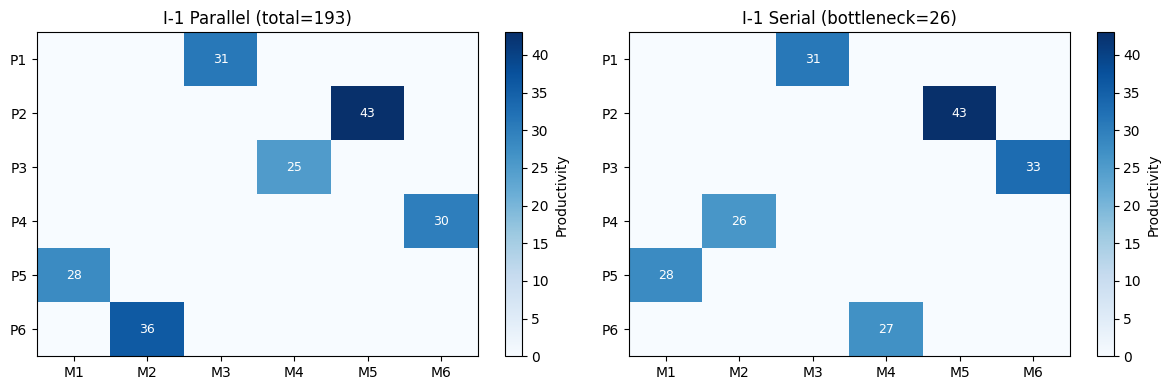

In [ ]:
if "par_sol" in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, sol, title in [
        (axes[0], par_sol, f"I-1 Parallel (total={obj_par:.0f})"),
        (axes[1], ser_sol, f"I-1 Serial (bottleneck={obj_ser:.0f})"),
    ]:
        matrix = np.array([[OUTP[(p,m)] * (sol.get((p,m),0) > 0.5)
                            for m in range(1,7)] for p in range(1,7)])
        im = ax.imshow(matrix, cmap="Blues", aspect="auto")
        plt.colorbar(im, ax=ax, label="Productivity")
        ax.set_xticks(range(6)); ax.set_xticklabels([f"M{m}" for m in range(1,7)])
        ax.set_yticks(range(6)); ax.set_yticklabels([f"P{p}" for p in range(1,7)])
        for p in range(6):
            for m in range(6):
                if matrix[p,m] > 0:
                    ax.text(m, p, str(matrix[p,m]), ha="center", va="center",
                            fontsize=9, color="white")
        ax.set_title(title)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping assignment chart")

## I-2 Nurse scheduling (IP)

*Applications Book Chapter I, Example 2*

> **Mosel model:** [`i2nurse_p.mos`](models/timetabling_personnel/i2nurse_p.mos)

A hospital schedules nurses across 12 two-hour periods in a day. Nurses work 8 consecutive hours (4 periods) with a 2-hour break after 6 hours; they may start in any period. The model first minimizes total nurse headcount. A second variant caps the total at 80 nurses and minimizes overtime (nurses who extend shifts into an adjacent period).

The demand constraints are modeled as named `linctr` objects (`Period`) which are reassigned in-place when extending the model for overtime, without removing and recreating constraints.

**Sets:** $\text{PERIODS} = \{0..11\}$, $\text{WORK} = \{0,-1,-3,-4\}$

**Decision variables:** $\mathit{start}_t \in \mathbb{Z}_{\geq 0}$ - nurses starting in period $t$; $\mathit{overt}_t$ - nurses working overtime in period $t$ (variant 2)

$$
\begin{align*}
\text{(v1)} \quad \text{minimize} \quad & \sum_t \mathit{start}_t \\
\text{subject to} \quad & \sum_{i \in \text{WORK}} \mathit{start}_{(t+i) \bmod 12} \geq \text{REQ}_t \quad \forall\, t
\end{align*}
$$

Define hourly nurse requirements as a 0-indexed dict. The second variant's staff cap is set via `exec_params`.

In [ ]:
REQ = {0:15, 1:15, 2:15, 3:35, 4:40, 5:40, 6:35, 7:30, 8:30, 9:35, 10:30, 11:20}
NUM = 80  # staff cap for variant 2

period_labels = [f"{t*2:02d}:00" for t in range(12)]
print("Nurse requirements per 2-hour period:")
for t in range(12):
    print(f"  {period_labels[t]}-{(t+1)*2:02d}:00: {REQ[t]:>3} nurses required")

Nurse requirements per 2-hour period:
  00:00-02:00:  15 nurses required
  02:00-04:00:  15 nurses required
  04:00-06:00:  15 nurses required
  06:00-08:00:  35 nurses required
  08:00-10:00:  40 nurses required
  10:00-12:00:  40 nurses required
  12:00-14:00:  35 nurses required
  14:00-16:00:  30 nurses required
  16:00-18:00:  30 nurses required
  18:00-20:00:  35 nurses required
  20:00-22:00:  30 nurses required
  22:00-24:00:  20 nurses required


Use the compile-load-run sequence to allow rerunning with different `NUM` values. The model solves both variants in a single `run()` call, returning results for minimum headcount (`obj_total`, `sol_start1`) and minimum overtime (`obj_overt`, `sol_start2`, `sol_overt`).

Named `linctr` constraints (`Period`) are redefined inside the model between the two solves - this is a key Mosel capability for progressively tightening or modifying a formulation without starting over.

In [ ]:
mp.compile_model(f"{MODELS}/i2nurse_p.mos", f"{MODELS}/i2nurse_p.bim")
model = mp.load_model(f"{MODELS}/i2nurse_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "NUM": NUM},
    input_data={"REQ": REQ},
)

if model.prob_status.is_solution_available:
    obj_total  = output["obj_total"]
    obj_overt  = output["obj_overt"]
    sol_start1 = output["sol_start1"]
    sol_start2 = output["sol_start2"]
    sol_overt  = output["sol_overt"]

    print(f"Variant 1 - minimum total nurses: {obj_total:.0f}")
    print(f"Variant 2 - overtime nurses (cap={NUM}): {obj_overt:.0f}")
    print()
    print(f"{'Period':<12} {'Req':>4} {'Start v1':>9} {'Start v2':>9} {'Overtime':>9}")
    for t in range(12):
        s1 = round(sol_start1.get(t, 0))
        s2 = round(sol_start2.get(t, 0))
        ov = round(sol_overt.get(t, 0))
        print(f"  {period_labels[t]:<10} {REQ[t]:>4} {s1:>9} {s2:>9} {ov:>9}")
else:
    print(f"No solution found ({model.prob_status})")

Variant 1 - minimum total nurses: 100
Variant 2 - overtime nurses (cap=80): 40

Period        Req  Start v1  Start v2  Overtime
  00:00        15         0         0         0
  02:00        15         0         0         0
  04:00        15         5         0         0
  06:00        35        10        15         0
  08:00        40        30        15         5
  10:00        40         5        25        15
  12:00        35        15         0         0
  14:00        30         0         0         0
  16:00        30         0         0         0
  18:00        35        15         5         0
  20:00        30         0        10        10
  22:00        20        20        10        10


Two-panel chart for both variants. Bars show nurses *starting* their shift in each period; these are always lower than the requirement because a single nurse covers 4 consecutive periods (at offsets 0, 1, 3, 4 from start time). The orange line shows total *active* nurses per period (summing starters at those offsets), which meets or exceeds the red requirement line at every period.

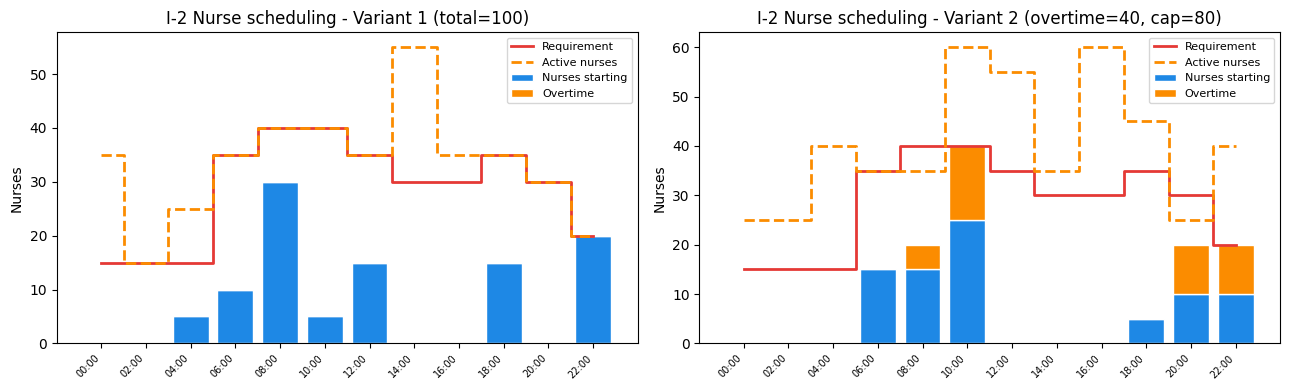

In [ ]:
if "sol_start1" in locals():
    s1 = [round(sol_start1.get(t, 0)) for t in range(12)]
    s2 = [round(sol_start2.get(t, 0)) for t in range(12)]
    ov = [round(sol_overt.get(t, 0)) for t in range(12)]
    req = [REQ[t] for t in range(12)]

    # Active nurses per period: sum of starters at offsets {0,-1,-3,-4}
    offsets = [0, -1, -3, -4]
    active1 = [sum(s1[(t + o) % 12] for o in offsets) for t in range(12)]
    active2 = [sum(s2[(t + o) % 12] + ov[(t + o) % 12] for o in offsets) for t in range(12)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, starts, overt_vals, active, title in [
        (axes[0], s1, [0]*12, active1, f"Variant 1 (total={obj_total:.0f})"),
        (axes[1], s2, ov,     active2, f"Variant 2 (overtime={obj_overt:.0f}, cap={NUM})"),
    ]:
        ax.bar(range(12), starts, color="#1E88E5", label="Nurses starting", edgecolor="white")
        ax.bar(range(12), overt_vals, bottom=starts, color="#FB8C00",
               label="Overtime", edgecolor="white")
        ax.step(range(12), req, where="mid", color="#E53935", linewidth=2,
                label="Requirement")
        ax.step(range(12), active, where="mid", color="#FB8C00", linewidth=2,
                linestyle="--", label="Active nurses")
        ax.set_xticks(range(12))
        ax.set_xticklabels(period_labels, rotation=45, ha="right", fontsize=7)
        ax.set_ylabel("Nurses")
        ax.set_title(f"I-2 Nurse scheduling - {title}")
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping nurse schedule chart")

## I-3 School timetable (IP)

*Applications Book Chapter I, Example 3*

> **Mosel model:** [`i3school_p.mos`](models/timetabling_personnel/i3school_p.mos)

A weekly timetable must be determined for two classes sharing nine teachers. Teachers have specific lesson counts per class and subject. The objective minimizes 'holes' - courses scheduled at the start or end of a day, which leave gaps in the students' timetable. Several hard constraints encode specific scheduling requirements (sport on Thursday afternoon, no Monday morning lessons, etc.).

**Sets:** $\text{TEACHERS}$ (9 teachers, auto-populated), $\text{CLASS} = \{1,2\}$, $\text{SLOTS} = 1..20$ (5 days x 4 periods)

**Parameters:** $\text{COURSE}_{t,c}$ - lessons teacher $t$ must give to class $c$

**Decision variables:** $\mathit{teach}_{t,c,l} \in \{0,1\}$ - 1 if teacher $t$ gives class $c$ in slot $l$

Define the lesson counts as a dict with `(teacher_name, class)` tuple keys. The `TEACHERS` set of strings auto-populates from the dict keys. The slot structure uses 4 periods per day across 5 days (slots 1-4 = Monday, 5-8 = Tuesday, ..., 17-20 = Friday).

In [ ]:
COURSE = {
    ("Mr Cheese",    1): 1, ("Mr Cheese",    2): 1,
    ("Mrs Insulin",  1): 3, ("Mrs Insulin",  2): 3,
    ("Mr Map",       1): 2, ("Mr Map",       2): 2,
    ("Mr Effofecks", 1): 0, ("Mr Effofecks", 2): 4,
    ("Mrs Derivate", 1): 4, ("Mrs Derivate", 2): 0,
    ("Mrs Electron", 1): 3, ("Mrs Electron", 2): 3,
    ("Mr Wise",      1): 1, ("Mr Wise",      2): 1,
    ("Mr Muscle",    1): 1, ("Mr Muscle",    2): 0,
    ("Mrs Biceps",   1): 0, ("Mrs Biceps",   2): 1,
}
TEACHERS = sorted({t for (t, _) in COURSE})
NP, ND = 4, 5  # periods per day, days per week
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri"]

total_lessons = {c: sum(COURSE.get((t,c),0) for t in TEACHERS) for c in [1,2]}
print(f"Total lessons: Class 1 = {total_lessons[1]}, Class 2 = {total_lessons[2]}")
print(f"Slots = {NP} periods/day x {ND} days = {NP*ND} total")

Total lessons: Class 1 = 15, Class 2 = 15
Slots = 4 periods/day x 5 days = 20 total


Use the single execution command. `COURSE` is the only required input; the `TEACHERS` set auto-populates from the dict keys. The result `sol_teach` is a dict with `(teacher, class, slot)` keys.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/i3school_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"COURSE": COURSE},
)

if model.prob_status.is_solution_available:
    obj_val_i3 = output["obj_val"]
    sol_teach  = output["sol_teach"]

    print(f"Courses at start/end of day (holes): {obj_val_i3:.0f}")
    print()

    # Reconstruct timetable for each class
    for cls in [1, 2]:
        print(f"Class {cls} timetable:")
        for d in range(ND):
            day_slots = range(d*NP+1, (d+1)*NP+1)
            assigned = {}
            for l in day_slots:
                for t in TEACHERS:
                    if sol_teach.get((t, cls, l), 0) > 0.5:
                        assigned[l] = t
            slot_strs = [f"  {assigned.get(l,'(free)'):<18}" for l in day_slots]
            print(f"  {DAY_NAMES[d]}: {''.join(slot_strs)}")
        print()
else:
    print(f"No solution found ({model.prob_status})")

Courses at start/end of day (holes): 10

Class 1 timetable:
  Mon:   (free)              Mrs Derivate        Mr Wise             (free)            
  Tue:   Mrs Derivate        Mrs Electron        Mrs Insulin         (free)            
  Wed:   (free)              Mrs Electron        Mr Map              Mr Cheese         
  Thu:   Mrs Derivate        Mrs Insulin         Mr Muscle           (free)            
  Fri:   Mrs Derivate        Mr Map              Mrs Insulin         Mrs Electron      

Class 2 timetable:
  Mon:   (free)              Mrs Insulin         Mr Map              (free)            
  Tue:   (free)              Mr Wise             Mr Effofecks        Mrs Electron      
  Wed:   (free)              Mr Effofecks        Mrs Electron        (free)            
  Thu:   Mr Effofecks        Mr Map              Mrs Biceps          Mrs Insulin       
  Fri:   Mrs Electron        Mrs Insulin         Mr Effofecks        Mr Cheese         



Timetable grid for each class: rows = days, columns = periods. Colored cells show which teacher is assigned; empty cells are free periods.

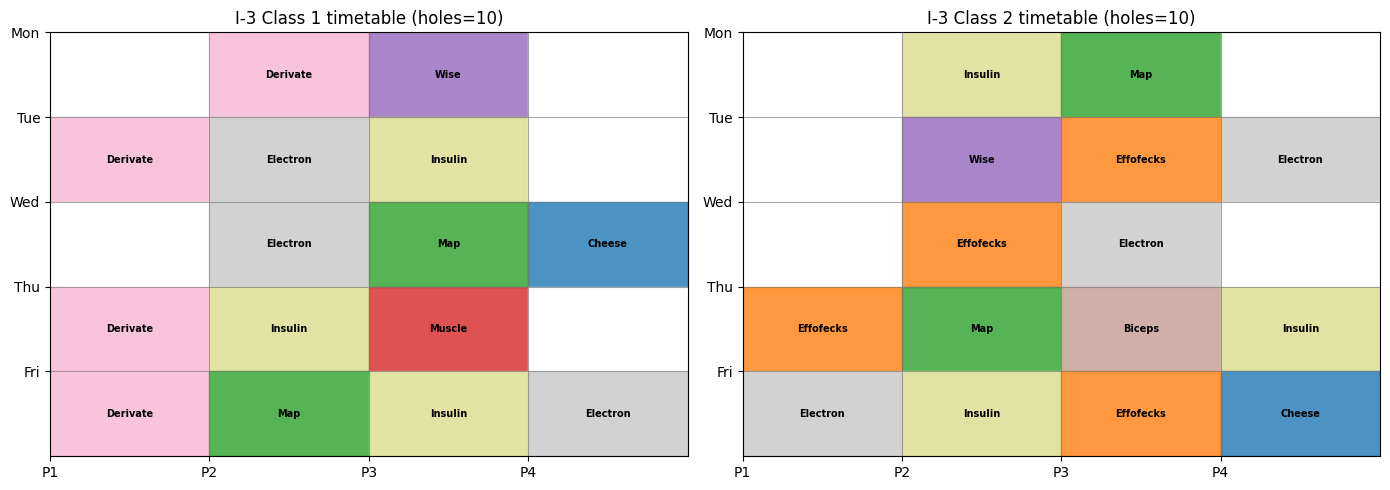

In [ ]:
if "sol_teach" in locals():
    teacher_colors = {t: plt.cm.tab20(i/len(TEACHERS))
                      for i, t in enumerate(sorted(TEACHERS))}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for cls, ax in enumerate([axes[0], axes[1]], start=1):
        grid = np.zeros((ND, NP))
        annotations = [["" for _ in range(NP)] for _ in range(ND)]
        cell_colors = [["white" for _ in range(NP)] for _ in range(ND)]

        for d in range(ND):
            for p in range(NP):
                l = d * NP + p + 1
                for t in TEACHERS:
                    if sol_teach.get((t, cls, l), 0) > 0.5:
                        annotations[d][p] = t.split()[-1]  # last name only
                        cell_colors[d][p] = teacher_colors[t]

        ax.set_xlim(0, NP); ax.set_ylim(0, ND)
        ax.set_xticks(range(NP)); ax.set_xticklabels([f"P{p+1}" for p in range(NP)])
        ax.set_yticks(range(ND)); ax.set_yticklabels(DAY_NAMES)
        ax.invert_yaxis()

        for d in range(ND):
            for p in range(NP):
                color = cell_colors[d][p]
                ax.add_patch(plt.Rectangle((p, d), 1, 1, color=color, alpha=0.8))
                if annotations[d][p]:
                    ax.text(p+0.5, d+0.5, annotations[d][p],
                            ha="center", va="center", fontsize=7, fontweight="bold")

        ax.set_title(f"I-3 Class {cls} timetable (holes={obj_val_i3:.0f})")
        ax.grid(True, color="gray", linewidth=0.5)

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping timetable chart")

## I-4 Exam scheduling (IP, feasibility)

*Applications Book Chapter I, Example 4*

> **Mosel model:** [`i4exam_p.mos`](models/timetabling_personnel/i4exam_p.mos)

Eleven exams must be scheduled across 8 time slots for fourth-year students. Students taking certain pairs of exams cannot have them in the same slot (incompatibility constraints). Since any valid schedule is acceptable, there is no objective - the model finds a feasible assignment by minimizing 0.

This demonstrates how to use MoselPy for **feasibility problems**: `model.prob_status.is_solution_available` is checked (not `is_solution_optimal`) since there is no meaningful objective value to verify.

**Sets:** $\text{EXAM}$ (11 exams, auto-populated from `INCOMP`), $\text{TIME} = 1..8$

**Parameters:** $\text{INCOMP}_{d,e}$ - 1 if exams $d$ and $e$ cannot be in the same slot

**Decision variables:** $\mathit{plan}_{e,t} \in \{0,1\}$ - 1 if exam $e$ scheduled in slot $t$

Define the incompatibility matrix as a dict with `(exam1, exam2)` string tuple keys. The `EXAM` set auto-populates from the dict keys. Only entries equal to 1 need to be listed; missing entries default to 0.

In [ ]:
EXAM_NAMES = ["DA","NA","C++","SE","PM","J","GMA","LP","MP","S","DSE"]

incomp_pairs = [
    ("DA","NA"),("DA","PM"),("DA","GMA"),("DA","S"),("DA","DSE"),
    ("NA","DA"),("NA","PM"),("NA","GMA"),("NA","S"),("NA","DSE"),
    ("C++","SE"),("C++","PM"),("C++","J"),("C++","GMA"),("C++","MP"),("C++","S"),("C++","DSE"),
    ("SE","C++"),("SE","PM"),("SE","J"),("SE","GMA"),("SE","S"),("SE","DSE"),
    ("PM","DA"),("PM","NA"),("PM","C++"),("PM","SE"),("PM","J"),
    ("PM","GMA"),("PM","LP"),("PM","MP"),("PM","S"),("PM","DSE"),
    ("J","C++"),("J","SE"),("J","PM"),("J","GMA"),("J","MP"),("J","S"),("J","DSE"),
    ("GMA","DA"),("GMA","NA"),("GMA","C++"),("GMA","SE"),("GMA","PM"),
    ("GMA","J"),("GMA","LP"),("GMA","MP"),("GMA","S"),("GMA","DSE"),
    ("LP","PM"),("LP","GMA"),("LP","S"),("LP","DSE"),
    ("MP","C++"),("MP","PM"),("MP","J"),("MP","GMA"),("MP","S"),("MP","DSE"),
    ("S","DA"),("S","NA"),("S","C++"),("S","SE"),("S","PM"),
    ("S","J"),("S","GMA"),("S","LP"),("S","MP"),("S","DSE"),
    ("DSE","DA"),("DSE","NA"),("DSE","C++"),("DSE","SE"),("DSE","PM"),
    ("DSE","J"),("DSE","GMA"),("DSE","LP"),("DSE","MP"),("DSE","S"),
]
INCOMP = {pair: 1 for pair in incomp_pairs}

print(f"Exams to schedule: {EXAM_NAMES}")
print(f"Incompatibility pairs: {len(incomp_pairs)}")
print(f"Available time slots: 8")

Exams to schedule: ['DA', 'NA', 'C++', 'SE', 'PM', 'J', 'GMA', 'LP', 'MP', 'S', 'DSE']
Incompatibility pairs: 80
Available time slots: 8


Use the single execution command. Since the objective is 0 (feasibility), `is_solution_available` is the relevant check - `is_solution_optimal` would also be true since minimizing 0 trivially achieves optimality. `sol_plan` maps `(exam, slot)` pairs to binary values.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/i4exam_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"INCOMP": INCOMP},
)

if model.prob_status.is_solution_available:
    sol_plan = output["sol_plan"]

    # Derive slot assignment for each exam
    slot_of = {e: t for (e, t), v in sol_plan.items() if v > 0.5}
    print(f"Feasible exam schedule found:")
    print()
    for t in range(1, 9):
        exams_in_slot = sorted(e for e, s in slot_of.items() if s == t)
        print(f"  Slot {t}: {', '.join(exams_in_slot) if exams_in_slot else '(empty)'}")

    # Verify no incompatibilities violated
    violations = [(d, e) for (d, e), v in INCOMP.items()
                  if v == 1 and slot_of.get(d) == slot_of.get(e)]
    print(f"\nIncompatibility violations: {len(violations)} (should be 0)")
else:
    print(f"No feasible schedule found ({model.prob_status})")

Feasible exam schedule found:

  Slot 1: DA, J, LP
  Slot 2: PM
  Slot 3: GMA
  Slot 4: S
  Slot 5: DSE
  Slot 6: MP, NA, SE
  Slot 7: C++
  Slot 8: (empty)

Incompatibility violations: 0 (should be 0)


Slot assignment chart showing which exams are scheduled in each slot, with the incompatibility graph summarized as a heatmap.

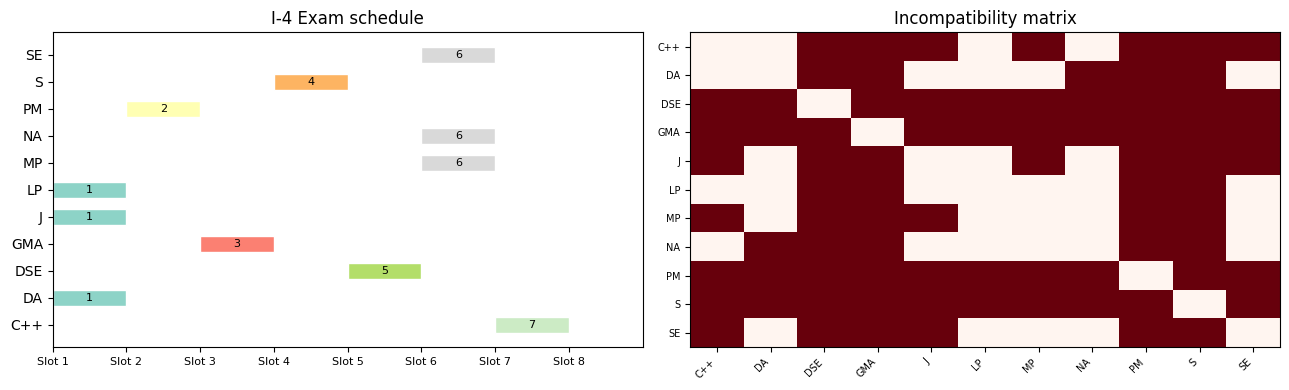

In [ ]:
if "sol_plan" in locals() and model.prob_status.is_solution_available:
    slot_of = {e: t for (e, t), v in sol_plan.items() if v > 0.5}
    exams_sorted = sorted(slot_of.keys())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: slot assignment timeline
    ax = axes[0]
    colors_slot = plt.cm.Set3(np.linspace(0, 1, 8))
    for e in exams_sorted:
        t = slot_of.get(e, 0) - 1
        ax.barh(e, 1, left=t, color=colors_slot[t], edgecolor="white", height=0.6)
        ax.text(t + 0.5, e, str(t+1), ha="center", va="center", fontsize=8)
    ax.set_xlim(0, 8)
    ax.set_xticks(range(8)); ax.set_xticklabels([f"Slot {t}" for t in range(1,9)], fontsize=8)
    ax.set_title("I-4 Exam schedule")

    # Right: incompatibility heatmap
    ax2 = axes[1]
    n = len(exams_sorted)
    incomp_matrix = np.array([
        [INCOMP.get((d, e), 0) for e in exams_sorted]
        for d in exams_sorted
    ])
    im = ax2.imshow(incomp_matrix, cmap="Reds", aspect="auto")
    ax2.set_xticks(range(n)); ax2.set_xticklabels(exams_sorted, rotation=45, ha="right", fontsize=7)
    ax2.set_yticks(range(n)); ax2.set_yticklabels(exams_sorted, fontsize=7)
    ax2.set_title("Incompatibility matrix")

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping exam chart")

## I-5 Production planning with personnel (LP)

*Applications Book Chapter I, Example 5*

> **Mosel model:** [`i5pplan_p.mos`](models/timetabling_personnel/i5pplan_p.mos)

A company produces four products on five production lines. Processing times and line capacities are known. In a first solve, no transfers are allowed. In a second solve, working hours can be transferred between certain line pairs (up to a maximum per line). Maximize total profit in both cases.

Transfer variables are created via `create()` only for permitted line pairs (dynamic array). Named `linctr` constraints (`Load`) are reassigned in-place to replace fixed-capacity limits with effective-hours limits, without removing the existing constraints.

**Sets:** $\text{PRODS} = 1..4$, $\text{LINES} = 1..5$

**Parameters:** $\text{DUR}_{p,l}$, $\text{CAP}_l$, $\text{PROFIT}_p$, $\text{TRANSF}_{k,l}$, $\text{TMAX}_l$

**Decision variables:** $\mathit{produce}_p \geq 0$; $\mathit{hours}_l \geq 0$; $\mathit{transfer}_{k,l} \geq 0$ (if permitted)

Define the duration matrix, capacities, and profits as 1-indexed dicts. `TRANSF` is a sparse dict indicating which transfers are allowed (only entries with value 1 are needed). `TMAX` caps outgoing transfers per line.

In [ ]:
dur_raw = [[1.3,0.9,2.0,0.3,0.9],[1.8,1.7,1.4,0.6,1.1],
           [1.3,1.2,1.3,1.0,1.4],[0.9,1.1,1.0,0.9,1.0]]
DUR    = {(p+1,l+1): dur_raw[p][l] for p in range(4) for l in range(5)}
CAP    = {1:4500, 2:5000, 3:4500, 4:1500, 5:2500}
PROFIT = {1:7, 2:8, 3:9, 4:7}
TRANSF = {(1,2):1,(1,3):1,(1,4):1,
          (2,3):1,(2,5):1,
          (3,1):1,(3,2):1,(3,4):1,
          (4,5):1,
          (5,1):1,(5,2):1,(5,3):1}
TMAX   = {1:400, 2:800, 3:200, 4:500, 5:300}

print("Permitted transfer routes:")
for (k,l) in sorted(TRANSF):
    print(f"  Line {k} -> Line {l}  (max from line {k}: {TMAX[k]} hrs)")

Permitted transfer routes:
  Line 1 -> Line 2  (max from line 1: 400 hrs)
  Line 1 -> Line 3  (max from line 1: 400 hrs)
  Line 1 -> Line 4  (max from line 1: 400 hrs)
  Line 2 -> Line 3  (max from line 2: 800 hrs)
  Line 2 -> Line 5  (max from line 2: 800 hrs)
  Line 3 -> Line 1  (max from line 3: 200 hrs)
  Line 3 -> Line 2  (max from line 3: 200 hrs)
  Line 3 -> Line 4  (max from line 3: 200 hrs)
  Line 4 -> Line 5  (max from line 4: 500 hrs)
  Line 5 -> Line 1  (max from line 5: 300 hrs)
  Line 5 -> Line 2  (max from line 5: 300 hrs)
  Line 5 -> Line 3  (max from line 5: 300 hrs)


Use the compile-load-run sequence to allow running with different capacities. The model solves both variants in a single call. `Load` constraints are redefined in-place inside the Mosel model between the two solves: this is a key feature for extending a model without re-specifying all constraints.

In [ ]:
mp.compile_model(f"{MODELS}/i5pplan_p.mos", f"{MODELS}/i5pplan_p.bim")
model = mp.load_model(f"{MODELS}/i5pplan_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"PROFIT": PROFIT, "DUR": DUR, "CAP": CAP, "TRANSF": TRANSF, "TMAX": TMAX},
)

if model.prob_status.is_solution_available:
    obj_notrans   = output["obj_notrans"]
    obj_trans     = output["obj_trans"]
    sol_produce1  = output["sol_produce1"]
    sol_produce2  = output["sol_produce2"]
    sol_transfer  = output["sol_transfer"]

    print(f"Without transfers: total profit = {obj_notrans:,.1f}")
    for p in range(1, 5):
        print(f"  Product {p}: {sol_produce1.get(p,0):,.2f} units")

    print(f"\nWith transfers: total profit = {obj_trans:,.1f}  (+{obj_trans-obj_notrans:,.1f})")
    for p in range(1, 5):
        print(f"  Product {p}: {sol_produce2.get(p,0):,.2f} units")

    active_transfers = {(k,l): v for (k,l),v in sol_transfer.items() if v > 0.01}
    if active_transfers:
        print("\nHours transferred:")
        for (k,l),v in sorted(active_transfers.items()):
            print(f"  Line {k} -> Line {l}: {v:,.1f} hrs")
else:
    print(f"No solution found ({model.prob_status})")

Without transfers: total profit = 18,883.0
  Product 1: 1,542.55 units
  Product 2: 1,010.64 units
  Product 3: 0.00 units
  Product 4: 0.00 units

With transfers: total profit = 23,431.1  (+4,548.1)
  Product 1: 702.35 units
  Product 2: 942.82 units
  Product 3: 554.25 units
  Product 4: 854.84 units

Hours transferred:
  Line 1 -> Line 4: 400.0 hrs
  Line 2 -> Line 5: 800.0 hrs
  Line 3 -> Line 4: 200.0 hrs


Side-by-side comparison of production volumes without and with personnel transfers, plus a transfer flow diagram.

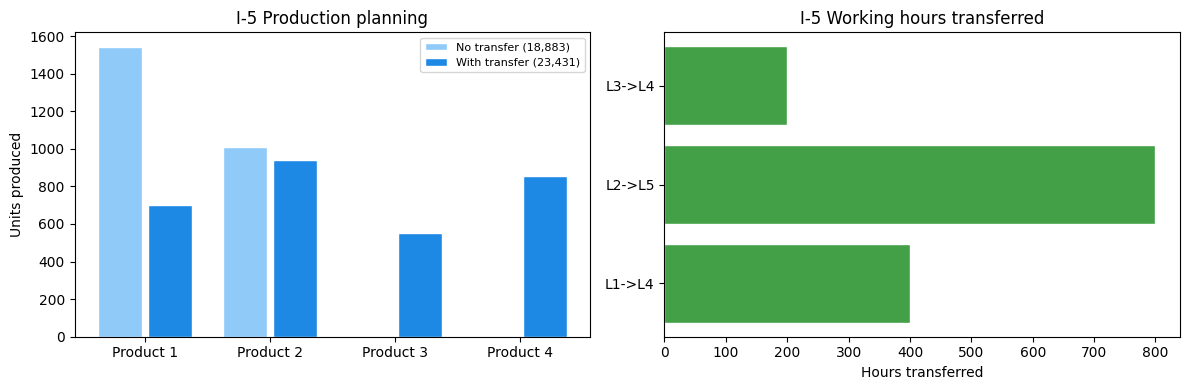

In [ ]:
if "sol_produce1" in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: production comparison
    ax = axes[0]
    x = np.arange(4)
    p1 = [sol_produce1.get(p, 0) for p in range(1, 5)]
    p2 = [sol_produce2.get(p, 0) for p in range(1, 5)]
    ax.bar(x - 0.2, p1, 0.35, label=f"No transfer ({obj_notrans:,.0f})",
           color="#90CAF9", edgecolor="white")
    ax.bar(x + 0.2, p2, 0.35, label=f"With transfer ({obj_trans:,.0f})",
           color="#1E88E5", edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels([f"Product {p}" for p in range(1,5)])
    ax.set_ylabel("Units produced")
    ax.set_title("I-5 Production planning")
    ax.legend(fontsize=8)

    # Right: transfer flows
    ax2 = axes[1]
    active_t = {(k,l): v for (k,l),v in sol_transfer.items() if v > 0.01}
    lines_with_flow = sorted(set(k for k,l in active_t) | set(l for k,l in active_t))
    if active_t:
        labels_t = [f"L{k}->L{l}" for k,l in sorted(active_t)]
        values_t = [active_t[(k,l)] for k,l in sorted(active_t)]
        ax2.barh(labels_t, values_t, color="#43A047", edgecolor="white")
        ax2.set_xlabel("Hours transferred")
        ax2.set_title("I-5 Working hours transferred")
    else:
        ax2.text(0.5, 0.5, "No transfers active", ha="center", va="center",
                 transform=ax2.transAxes)
        ax2.set_title("I-5 Working hours transferred")

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping production chart")

## I-6 Construction site personnel planning (IP)

*Applications Book Chapter I, Example 6*

> **Mosel model:** [`i6build_p.mos`](models/timetabling_personnel/i6build_p.mos)

A company plans its workforce at a construction site over 6 months (March to August). Workers may arrive from other sites (up to 3 per month) or depart (up to 1/3 of current staff). Overstaffing and understaffing each carry a penalty cost per worker per month. The target is to end at the same staff level as the start. Minimize total cost.

**Sets:** $\text{MONTHS} = \{3..8\}$ (March to August)

**Parameters:** $\text{REQ}_m$, $\text{CARR}$, $\text{CLEAVE}$, $\text{COVER}$, $\text{CUNDER}$, $\text{NSTART}$, $\text{NFINAL}$

**Decision variables:** $\mathit{onsite}_m$, $\mathit{arrive}_m$, $\mathit{leave}_m$, $\mathit{over}_m$, $\mathit{under}_m \in \mathbb{Z}_{\geq 0}$

$$
\begin{align*}
\text{minimize} \quad & \sum_m (\text{CARR} \cdot \mathit{arrive}_m + \text{CLEAVE} \cdot \mathit{leave}_m + \text{COVER} \cdot \mathit{over}_m + \text{CUNDER} \cdot \mathit{under}_m)
\end{align*}
$$

Define the monthly worker requirements and all cost/staffing parameters as Python scalars and dicts. The planning horizon is months 3-8 (March to August).

In [ ]:
MONTH_NAMES = {3:"Mar", 4:"Apr", 5:"May", 6:"Jun", 7:"Jul", 8:"Aug"}
REQ    = {3:4, 4:6, 5:7, 6:4, 7:6, 8:2}
CARR   = 100   # cost per worker arriving
CLEAVE = 160   # cost per worker leaving
COVER  = 200   # cost per worker overstaffed
CUNDER = 200   # cost per worker understaffed
NSTART = 3     # workers at start
NFINAL = 3     # required workers at end

print("Monthly requirements:")
for m, name in MONTH_NAMES.items():
    print(f"  {name}: {REQ[m]} workers required")
print(f"\nStart/end: {NSTART}/{NFINAL} workers")
print(f"Costs: arrive={CARR}, leave={CLEAVE}, over={COVER}, under={CUNDER}")

Monthly requirements:
  Mar: 4 workers required
  Apr: 6 workers required
  May: 7 workers required
  Jun: 4 workers required
  Jul: 6 workers required
  Aug: 2 workers required

Start/end: 3/3 workers
Costs: arrive=100, leave=160, over=200, under=200


Use the single execution command. All staffing data is passed via `input_data`. The planning horizon endpoints (`FIRST=3`, `LAST=8`) use the model defaults; they can be overridden via `exec_params` for different scenarios.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/i6build_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"REQ": REQ, "CARR": CARR, "CLEAVE": CLEAVE,
                "COVER": COVER, "CUNDER": CUNDER,
                "NSTART": NSTART, "NFINAL": NFINAL},
)

if model.prob_status.is_solution_available:
    obj_val_i6  = output["obj_val"]
    sol_onsite  = output["sol_onsite"]
    sol_arrive  = output["sol_arrive"]
    sol_leave   = output["sol_leave"]
    sol_over    = output["sol_over"]
    sol_under   = output["sol_under"]

    print(f"Total staffing cost: {obj_val_i6:,.0f}")
    print()
    print(f"{'Month':<6} {'Req':>4} {'OnSite':>7} {'Arrive':>7} {'Leave':>7} {'Over':>5} {'Under':>6}")
    for m in range(3, 9):
        print(f"  {MONTH_NAMES[m]:<4} {REQ[m]:>4} "
              f"{round(sol_onsite.get(m,0)):>7} {round(sol_arrive.get(m,0)):>7} "
              f"{round(sol_leave.get(m,0)):>7} {round(sol_over.get(m,0)):>5} "
              f"{round(sol_under.get(m,0)):>6}")
else:
    print(f"No solution found ({model.prob_status})")

Total staffing cost: 1,780

Month   Req  OnSite  Arrive   Leave  Over  Under
  Mar     4       4       1       0     0      0
  Apr     6       6       2       0     0      0
  May     7       6       0       1     0      1
  Jun     4       5       0       0     1      0
  Jul     6       5       0       1     0      1
  Aug     2       4       0       1     2      0


Staffing timeline showing workers on site each month (blue) with overstaffing (orange) stacked on top and the monthly requirement (red line). Note that the requirement is a *soft* target: understaffing is permitted by the model but penalized (cost `CUNDER` per worker per month). Months where `onsite < REQ` are shown with a hatched gap; this is the deliberate optimizer trade-off when the cost of extra arrivals or delayed departures exceeds the understaffing penalty.

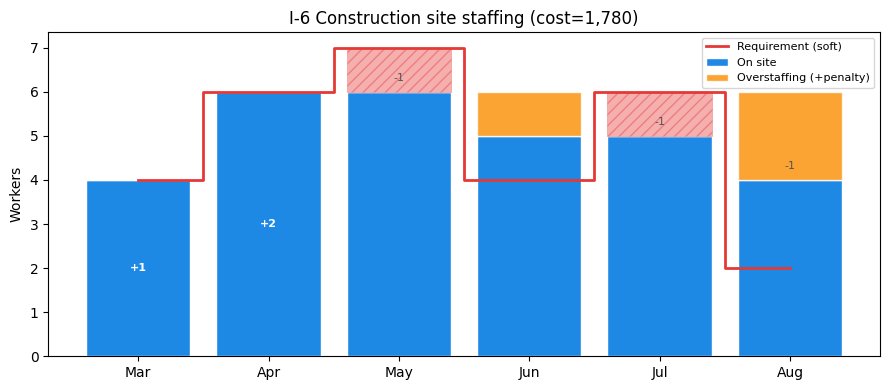

In [ ]:
if "sol_onsite" in locals():
    months = list(range(3, 9))
    names  = [MONTH_NAMES[m] for m in months]
    on_site = [round(sol_onsite.get(m, 0)) for m in months]
    arrives = [round(sol_arrive.get(m, 0)) for m in months]
    leaves  = [round(sol_leave.get(m, 0)) for m in months]
    overs   = [round(sol_over.get(m, 0)) for m in months]
    unders  = [round(sol_under.get(m, 0)) for m in months]
    reqs    = [REQ[m] for m in months]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(names, on_site, color="#1E88E5", label="On site", edgecolor="white")
    ax.bar(names, overs,   bottom=on_site, color="#FB8C00",
           label="Overstaffing (+penalty)", edgecolor="white", alpha=0.8)

    # Show understaffing gaps as hatched bars from onsite up to req
    for i, (s, r, u) in enumerate(zip(on_site, reqs, unders)):
        if u > 0:
            ax.bar(names[i], u, bottom=s, color="#E53935", alpha=0.4,
                   hatch="///", edgecolor="#E53935", linewidth=0.5,
                   label="Understaffing (+penalty)" if i == 0 else "")

    ax.step(range(6), reqs, where="mid", color="#E53935", linewidth=2,
            label="Requirement (soft)")

    # Annotate arrivals/departures
    for i, m in enumerate(months):
        a, l = arrives[i], leaves[i]
        if a > 0:
            ax.annotate(f"+{a}", (i, on_site[i]/2), ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")
        if l > 0:
            ax.annotate(f"-{l}", (i, on_site[i] + 0.2), ha="center", va="bottom",
                        fontsize=8, color="#555")

    ax.set_xticks(range(6)); ax.set_xticklabels(names)
    ax.set_ylabel("Workers")
    ax.set_title(f"I-6 Construction site staffing (cost={obj_val_i6:,.0f})")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping staffing chart")